
# 23CSE301 — Lab Session 07
## Decision Trees on the Sleep-EDF Project Dataset

**Project:** Hidden Semi-Markov Models for Personalized Sleep-Stage Transition Prediction  
**Dataset used in this notebook:** Sleep-EDF PSG + Hypnogram data  
**Classification task:** Sleep stage N2 (`Sleep stage 2`) vs N3 (`Sleep stage 3`)

### Assignment coverage
This notebook covers all Lab 07 tasks:

- **A1:** Custom entropy calculation
- **A2:** Custom Gini-index calculation
- **A3:** Custom root-feature detection using Information Gain
- **A4:** Custom equal-width/equal-frequency binning with default parameters
- **A5:** Custom Decision Tree module
- **A6:** Visualization of the custom Decision Tree
- **A7:** Two-feature Decision Tree decision-boundary visualization
- **A8:** Hyperparameter tuning using `GridSearchCV`

The notebook keeps the Sleep-EDF feature representation consistent with the earlier kNN work: five PSG channels, six time-domain statistics per channel, and four EEG band-power features for each of the two EEG channels, giving **38 features** when the expected channels are present.

> **Important:** The Lab 07 PDF explicitly states that GenAI tools must not be used for coding work in this lab. Use this notebook as a study/reference scaffold and make sure your submitted work complies with your instructor's rule.



## Coding constraints implemented

The assignment requires modular code, proper variable naming, inline comments, and **no `print()` statements inside functions**.  
Accordingly, all custom functions used in this notebook are defined together in **one code cell**, while outputs are printed only from the main-program cells.

For A4, Python does not support C/C++-style function overloading by signature. The required default behavior is implemented through default arguments:

```python
bin_continuous_feature(values, binning_type='equal_width', n_bins=4, edges=None)
```

Thus, calling the function without specifying the binning type or number of bins automatically uses **equal-width binning with four bins**.


In [2]:
# ============================================================
# LAB 07 — DEPENDENCY CHECK + IMPORTS
# ============================================================

import sys
import subprocess
import importlib.util


# ------------------------------------------------------------
# Install MNE automatically if it is not available
# ------------------------------------------------------------

if importlib.util.find_spec("mne") is None:
    print("MNE is not installed. Installing MNE...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "mne"
    ])

    print("MNE installation completed.")


# ------------------------------------------------------------
# Standard imports
# ------------------------------------------------------------

import os
import glob
import zipfile
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne


# ------------------------------------------------------------
# Scikit-learn imports
# ------------------------------------------------------------

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("All imports completed successfully.")
print("MNE version:", mne.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

MNE is not installed. Installing MNE...
MNE installation completed.
All imports completed successfully.
MNE version: 1.13.2
NumPy version: 2.1.3
Pandas version: 2.2.3


In [3]:

# ============================================================
# ALL CUSTOM FUNCTIONS FOR LAB 07
# ============================================================
# Requirement followed:
#   - All functions are in this single code block.
#   - No print() statement is used inside any function.
# ============================================================


# ------------------------------------------------------------
# DATA DISCOVERY / EXTRACTION
# ------------------------------------------------------------

def extract_zip_archives(search_root="/content", extraction_folder="sleep_edf_extracted"):
    """Extract valid ZIP files found under search_root, once per archive."""
    extracted_locations = []
    extraction_root = os.path.join(search_root, extraction_folder)
    os.makedirs(extraction_root, exist_ok=True)

    zip_paths = glob.glob(
        os.path.join(search_root, "**", "*.zip"),
        recursive=True
    )

    for zip_path in sorted(zip_paths):
        if not zipfile.is_zipfile(zip_path):
            continue

        archive_name = os.path.splitext(os.path.basename(zip_path))[0]
        archive_output = os.path.join(extraction_root, archive_name)
        marker_file = os.path.join(archive_output, ".extracted_ok")

        if os.path.exists(marker_file):
            extracted_locations.append(archive_output)
            continue

        os.makedirs(archive_output, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(archive_output)

        with open(marker_file, "w", encoding="utf-8") as marker:
            marker.write("ok")

        extracted_locations.append(archive_output)

    return extracted_locations


def discover_sleep_edf_pairs(search_root="/content"):
    """
    Recursively discover matched Sleep-EDF PSG/Hypnogram file pairs.
    Matching uses the first six filename characters, e.g. SC4001 / ST7011.
    """
    edf_paths = glob.glob(
        os.path.join(search_root, "**", "*"),
        recursive=True
    )

    edf_paths = [
        path for path in edf_paths
        if os.path.isfile(path) and path.lower().endswith(".edf")
    ]

    psg_paths = sorted([
        path for path in edf_paths
        if "psg" in os.path.basename(path).lower()
    ])

    hypnogram_paths = sorted([
        path for path in edf_paths
        if "hypnogram" in os.path.basename(path).lower()
    ])

    pairs = []

    for psg_path in psg_paths:
        psg_name = os.path.basename(psg_path)
        prefix = psg_name[:6].lower()

        matches = [
            hyp_path
            for hyp_path in hypnogram_paths
            if os.path.basename(hyp_path).lower().startswith(prefix)
        ]

        if matches:
            pairs.append((psg_path, matches[0]))

    return pairs


# ------------------------------------------------------------
# SLEEP-EDF LOADING / FEATURE EXTRACTION
# ------------------------------------------------------------

def load_sleep_edf_epochs(
    psg_path,
    hypnogram_path,
    required_channels=None,
    epoch_seconds=30
):
    """
    Load one matched Sleep-EDF PSG/Hypnogram pair and return 30-s epochs.
    """
    if required_channels is None:
        required_channels = [
            "EEG Fpz-Cz",
            "EEG Pz-Oz",
            "EOG horizontal",
            "Resp oro-nasal",
            "EMG submental"
        ]

    raw = mne.io.read_raw_edf(
        psg_path,
        preload=True,
        verbose=False
    )

    annotations = mne.read_annotations(
        hypnogram_path
    )

    raw.set_annotations(
        annotations,
        emit_warning=False
    )

    available_channels = raw.ch_names

    missing_channels = [
        channel
        for channel in required_channels
        if channel not in available_channels
    ]

    if missing_channels:
        raise ValueError(
            "Required Sleep-EDF channels are missing: "
            + ", ".join(missing_channels)
        )

    sampling_frequency = float(raw.info["sfreq"])

    signal_matrix = raw.get_data(
        picks=required_channels
    )

    samples_per_epoch = int(
        epoch_seconds * sampling_frequency
    )

    epoch_signals = []
    epoch_labels = []

    for onset, duration, description in zip(
        annotations.onset,
        annotations.duration,
        annotations.description
    ):
        sub_epoch_count = int(
            duration // epoch_seconds
        )

        for sub_epoch_index in range(sub_epoch_count):
            start_sample = int(
                (onset + sub_epoch_index * epoch_seconds)
                * sampling_frequency
            )

            end_sample = (
                start_sample
                + samples_per_epoch
            )

            if start_sample < 0:
                continue

            if end_sample > signal_matrix.shape[1]:
                continue

            epoch_signals.append(
                signal_matrix[:, start_sample:end_sample]
            )

            epoch_labels.append(
                description
            )

    return (
        epoch_signals,
        np.asarray(epoch_labels),
        sampling_frequency,
        list(required_channels)
    )


def calculate_band_power(
    signal_values,
    sampling_frequency,
    lower_frequency,
    upper_frequency
):
    """Calculate mean FFT power inside one frequency band."""
    signal_values = np.asarray(
        signal_values,
        dtype=float
    )

    frequencies = np.fft.rfftfreq(
        len(signal_values),
        d=1.0 / sampling_frequency
    )

    spectrum = np.abs(
        np.fft.rfft(signal_values)
    ) ** 2

    band_mask = (
        (frequencies >= lower_frequency)
        &
        (frequencies < upper_frequency)
    )

    if not np.any(band_mask):
        return 0.0

    return float(
        np.mean(spectrum[band_mask])
    )


def extract_epoch_features(
    epoch_signal,
    sampling_frequency,
    channel_names
):
    """
    Extract the same 38-feature representation used in the earlier project labs:
      - 6 statistics for each of 5 channels = 30
      - delta/theta/alpha/beta powers for two EEG channels = 8
      - total = 38 features
    """
    feature_values = []
    feature_names = []

    for channel_index, channel_name in enumerate(channel_names):
        signal_values = np.asarray(
            epoch_signal[channel_index],
            dtype=float
        )

        statistics = {
            "mean": np.mean(signal_values),
            "std": np.std(signal_values),
            "min": np.min(signal_values),
            "max": np.max(signal_values),
            "range": np.ptp(signal_values),
            "rms": np.sqrt(np.mean(signal_values ** 2))
        }

        for statistic_name, statistic_value in statistics.items():
            feature_names.append(
                f"{channel_name}_{statistic_name}"
            )
            feature_values.append(
                float(statistic_value)
            )

        if channel_index < 2:
            frequency_bands = {
                "delta": (0.5, 4.0),
                "theta": (4.0, 8.0),
                "alpha": (8.0, 13.0),
                "beta": (13.0, 30.0)
            }

            for band_name, (
                lower_frequency,
                upper_frequency
            ) in frequency_bands.items():
                feature_names.append(
                    f"{channel_name}_{band_name}_power"
                )

                feature_values.append(
                    calculate_band_power(
                        signal_values,
                        sampling_frequency,
                        lower_frequency,
                        upper_frequency
                    )
                )

    return (
        np.asarray(feature_values, dtype=float),
        feature_names
    )


def build_sleep_stage_dataset(
    epoch_signals,
    epoch_labels,
    sampling_frequency,
    channel_names,
    class_a="Sleep stage 2",
    class_b="Sleep stage 3"
):
    """Build the N2-vs-N3 project feature matrix."""
    feature_rows = []
    target_labels = []
    final_feature_names = None

    for epoch_signal, stage_label in zip(
        epoch_signals,
        epoch_labels
    ):
        if stage_label not in (class_a, class_b):
            continue

        features, names = extract_epoch_features(
            epoch_signal,
            sampling_frequency,
            channel_names
        )

        feature_rows.append(features)
        target_labels.append(stage_label)

        if final_feature_names is None:
            final_feature_names = names

    if len(feature_rows) == 0:
        raise ValueError(
            "No N2/N3 epochs were found in the selected recording."
        )

    feature_matrix = np.vstack(feature_rows)

    target_array = np.asarray(
        target_labels
    )

    return (
        feature_matrix,
        target_array,
        final_feature_names
    )


def encode_sleep_stage_labels(
    target_labels,
    class_a="Sleep stage 2",
    class_b="Sleep stage 3"
):
    """Encode N2 as 0 and N3 as 1."""
    mapping = {
        class_a: 0,
        class_b: 1
    }

    encoded = np.asarray([
        mapping[label]
        for label in target_labels
    ], dtype=int)

    return encoded, mapping


def replace_nonfinite_with_column_median(feature_matrix):
    """Replace NaN/Inf values using the median of each feature column."""
    clean_matrix = np.asarray(
        feature_matrix,
        dtype=float
    ).copy()

    clean_matrix[
        ~np.isfinite(clean_matrix)
    ] = np.nan

    for column_index in range(clean_matrix.shape[1]):
        column = clean_matrix[:, column_index]
        missing_mask = np.isnan(column)

        if not np.any(missing_mask):
            continue

        valid_values = column[~missing_mask]

        if valid_values.size == 0:
            fill_value = 0.0
        else:
            fill_value = float(
                np.median(valid_values)
            )

        clean_matrix[
            missing_mask,
            column_index
        ] = fill_value

    return clean_matrix


# ------------------------------------------------------------
# A1 — ENTROPY
# ------------------------------------------------------------

def calculate_entropy(labels):
    """
    Calculate Shannon entropy:
        H(Y) = -sum_i p_i log2(p_i)
    """
    labels = np.asarray(labels)

    if labels.size == 0:
        return 0.0

    _, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = (
        counts.astype(float)
        / counts.sum()
    )

    nonzero_probabilities = probabilities[
        probabilities > 0
    ]

    entropy_value = -np.sum(
        nonzero_probabilities
        * np.log2(nonzero_probabilities)
    )

    return float(entropy_value)


# ------------------------------------------------------------
# A2 — GINI INDEX
# ------------------------------------------------------------

def calculate_gini_index(labels):
    """
    Calculate Gini impurity:
        Gini(Y) = 1 - sum_i p_i^2
    """
    labels = np.asarray(labels)

    if labels.size == 0:
        return 0.0

    _, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = (
        counts.astype(float)
        / counts.sum()
    )

    gini_value = 1.0 - np.sum(
        probabilities ** 2
    )

    return float(gini_value)


# ------------------------------------------------------------
# A4 — BINNING
# ------------------------------------------------------------

def fit_binning_edges(
    values,
    binning_type="equal_width",
    n_bins=4
):
    """
    Learn bin edges for one continuous feature.

    Defaults satisfy the assignment's default-parameter requirement:
      binning_type='equal_width'
      n_bins=4
    """
    values = np.asarray(
        values,
        dtype=float
    )

    finite_values = values[
        np.isfinite(values)
    ]

    if finite_values.size == 0:
        raise ValueError(
            "Cannot create bins from a feature with no finite values."
        )

    if n_bins < 2:
        raise ValueError(
            "n_bins must be at least 2."
        )

    if binning_type == "equal_width":
        minimum_value = float(
            np.min(finite_values)
        )

        maximum_value = float(
            np.max(finite_values)
        )

        if np.isclose(
            minimum_value,
            maximum_value
        ):
            return np.array(
                [-np.inf, np.inf],
                dtype=float
            )

        edges = np.linspace(
            minimum_value,
            maximum_value,
            n_bins + 1
        )

    elif binning_type == "equal_frequency":
        quantiles = np.linspace(
            0.0,
            1.0,
            n_bins + 1
        )

        edges = np.quantile(
            finite_values,
            quantiles
        )

        edges = np.unique(edges)

        if len(edges) < 2:
            return np.array(
                [-np.inf, np.inf],
                dtype=float
            )

    else:
        raise ValueError(
            "binning_type must be 'equal_width' or 'equal_frequency'."
        )

    edges = np.asarray(
        edges,
        dtype=float
    )

    edges[0] = -np.inf
    edges[-1] = np.inf

    return edges


def apply_binning_edges(
    values,
    edges
):
    """Apply previously learned bin edges."""
    values = np.asarray(
        values,
        dtype=float
    )

    edges = np.asarray(
        edges,
        dtype=float
    )

    internal_edges = edges[1:-1]

    binned_values = np.digitize(
        values,
        internal_edges,
        right=False
    )

    return binned_values.astype(int)


def bin_continuous_feature(
    values,
    binning_type="equal_width",
    n_bins=4,
    edges=None
):
    """
    Convert a continuous feature into categorical bins.

    If edges are omitted, the function learns them.
    If edges are supplied, the same fitted bins are reused.
    """
    if edges is None:
        edges = fit_binning_edges(
            values,
            binning_type=binning_type,
            n_bins=n_bins
        )

    binned_values = apply_binning_edges(
        values,
        edges
    )

    return binned_values, edges


def bin_feature_matrix(
    feature_matrix,
    feature_names,
    binning_type="equal_width",
    n_bins=4,
    fitted_edges=None
):
    """
    Bin every continuous feature.

    When fitted_edges is None:
      fit edges and return them.

    Otherwise:
      reuse the supplied training edges.
    """
    feature_matrix = np.asarray(
        feature_matrix,
        dtype=float
    )

    binned_dataframe = pd.DataFrame(
        index=np.arange(
            feature_matrix.shape[0]
        )
    )

    learned_edges = {}

    for column_index, feature_name in enumerate(feature_names):
        values = feature_matrix[
            :,
            column_index
        ]

        if fitted_edges is None:
            binned_values, edges = bin_continuous_feature(
                values,
                binning_type=binning_type,
                n_bins=n_bins
            )

            learned_edges[
                feature_name
            ] = edges

        else:
            edges = fitted_edges[
                feature_name
            ]

            binned_values, _ = bin_continuous_feature(
                values,
                binning_type=binning_type,
                n_bins=n_bins,
                edges=edges
            )

        binned_dataframe[
            feature_name
        ] = binned_values

    if fitted_edges is not None:
        learned_edges = fitted_edges

    return (
        binned_dataframe,
        learned_edges
    )


# ------------------------------------------------------------
# A3 — INFORMATION GAIN / ROOT FEATURE
# ------------------------------------------------------------

def calculate_information_gain(
    labels,
    categorical_feature
):
    """
    Information Gain:
        IG(Y, X) = H(Y) - sum_v P(X=v) H(Y | X=v)
    """
    labels = np.asarray(labels)
    categorical_feature = np.asarray(
        categorical_feature
    )

    if len(labels) != len(categorical_feature):
        raise ValueError(
            "labels and feature must contain the same number of samples."
        )

    parent_entropy = calculate_entropy(
        labels
    )

    weighted_child_entropy = 0.0

    unique_values = np.unique(
        categorical_feature
    )

    for category_value in unique_values:
        mask = (
            categorical_feature
            == category_value
        )

        subset_labels = labels[
            mask
        ]

        subset_weight = (
            len(subset_labels)
            / len(labels)
        )

        weighted_child_entropy += (
            subset_weight
            * calculate_entropy(
                subset_labels
            )
        )

    information_gain = (
        parent_entropy
        - weighted_child_entropy
    )

    return float(
        information_gain
    )


def rank_features_by_information_gain(
    binned_dataframe,
    labels
):
    """Return all features ranked by Information Gain."""
    records = []

    for feature_name in binned_dataframe.columns:
        gain = calculate_information_gain(
            labels,
            binned_dataframe[
                feature_name
            ].to_numpy()
        )

        records.append({
            "feature": feature_name,
            "information_gain": gain
        })

    ranking = pd.DataFrame(
        records
    ).sort_values(
        "information_gain",
        ascending=False
    ).reset_index(
        drop=True
    )

    return ranking


def detect_root_feature(
    binned_dataframe,
    labels
):
    """Return the best root feature according to Information Gain."""
    ranking = rank_features_by_information_gain(
        binned_dataframe,
        labels
    )

    if ranking.empty:
        return None, 0.0, ranking

    root_feature = ranking.loc[
        0,
        "feature"
    ]

    root_gain = float(
        ranking.loc[
            0,
            "information_gain"
        ]
    )

    return (
        root_feature,
        root_gain,
        ranking
    )


# ------------------------------------------------------------
# A5 — CUSTOM DECISION TREE MODULE
# ------------------------------------------------------------

def majority_class(labels):
    """Return deterministic majority class."""
    labels = np.asarray(labels)

    values, counts = np.unique(
        labels,
        return_counts=True
    )

    return int(
        values[
            np.argmax(counts)
        ]
    )


def class_count_dictionary(labels):
    """Return class counts as a serializable dictionary."""
    values, counts = np.unique(
        np.asarray(labels),
        return_counts=True
    )

    return {
        int(value): int(count)
        for value, count
        in zip(values, counts)
    }


def build_custom_decision_tree(
    binned_dataframe,
    labels,
    available_features=None,
    depth=0,
    max_depth=3,
    min_samples_split=10,
    min_information_gain=1e-12
):
    """
    Build an ID3-style categorical Decision Tree using Information Gain.
    The continuous Sleep-EDF features must be binned before calling this.
    """
    labels = np.asarray(
        labels,
        dtype=int
    )

    if available_features is None:
        available_features = list(
            binned_dataframe.columns
        )

    prediction = majority_class(
        labels
    )

    node_common = {
        "prediction": prediction,
        "samples": int(len(labels)),
        "class_counts": class_count_dictionary(labels),
        "depth": int(depth)
    }

    # Pure node
    if len(np.unique(labels)) == 1:
        return {
            "type": "leaf",
            **node_common,
            "reason": "pure"
        }

    # Depth stop
    if depth >= max_depth:
        return {
            "type": "leaf",
            **node_common,
            "reason": "max_depth"
        }

    # Sample stop
    if len(labels) < min_samples_split:
        return {
            "type": "leaf",
            **node_common,
            "reason": "min_samples"
        }

    # No features remain
    if len(available_features) == 0:
        return {
            "type": "leaf",
            **node_common,
            "reason": "no_features"
        }

    best_feature = None
    best_gain = -np.inf

    for feature_name in available_features:
        gain = calculate_information_gain(
            labels,
            binned_dataframe[
                feature_name
            ].to_numpy()
        )

        if gain > best_gain:
            best_gain = gain
            best_feature = feature_name

    if (
        best_feature is None
        or
        best_gain <= min_information_gain
    ):
        return {
            "type": "leaf",
            **node_common,
            "reason": "low_gain"
        }

    remaining_features = [
        feature_name
        for feature_name in available_features
        if feature_name != best_feature
    ]

    node = {
        "type": "node",
        "feature": best_feature,
        "information_gain": float(best_gain),
        "branches": {},
        **node_common
    }

    feature_values = binned_dataframe[
        best_feature
    ].to_numpy()

    for category_value in sorted(
        np.unique(feature_values)
    ):
        mask = (
            feature_values
            == category_value
        )

        child_dataframe = (
            binned_dataframe
            .loc[mask, remaining_features]
            .reset_index(drop=True)
        )

        child_labels = labels[
            mask
        ]

        node["branches"][
            int(category_value)
        ] = build_custom_decision_tree(
            child_dataframe,
            child_labels,
            available_features=remaining_features,
            depth=depth + 1,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_information_gain=min_information_gain
        )

    return node


def predict_custom_tree_one(
    tree,
    binned_row
):
    """Predict one sample using the custom Decision Tree."""
    node = tree

    while node["type"] != "leaf":
        feature_name = node[
            "feature"
        ]

        feature_value = int(
            binned_row[
                feature_name
            ]
        )

        if feature_value not in node["branches"]:
            return int(
                node["prediction"]
            )

        node = node["branches"][
            feature_value
        ]

    return int(
        node["prediction"]
    )


def predict_custom_tree(
    tree,
    binned_dataframe
):
    """Predict all rows of a binned DataFrame."""
    predictions = []

    for _, row in binned_dataframe.iterrows():
        predictions.append(
            predict_custom_tree_one(
                tree,
                row
            )
        )

    return np.asarray(
        predictions,
        dtype=int
    )


def evaluate_binary_predictions(
    true_labels,
    predicted_labels
):
    """Return common binary-classification metrics."""
    return {
        "accuracy": accuracy_score(
            true_labels,
            predicted_labels
        ),
        "precision": precision_score(
            true_labels,
            predicted_labels,
            pos_label=1,
            zero_division=0
        ),
        "recall": recall_score(
            true_labels,
            predicted_labels,
            pos_label=1,
            zero_division=0
        ),
        "f1_score": f1_score(
            true_labels,
            predicted_labels,
            pos_label=1,
            zero_division=0
        )
    }


# ------------------------------------------------------------
# A6 — CUSTOM TREE VISUALIZATION
# ------------------------------------------------------------

def prepare_tree_layout(tree):
    """
    Create positions, labels, and edges for a custom tree diagram.
    Leaves receive sequential x positions; internal nodes are centered
    above their children.
    """
    positions = {}
    labels = {}
    edge_records = []
    leaf_counter = [0]

    def recursive_layout(
        node,
        path,
        depth
    ):
        if node["type"] == "leaf":
            x_position = leaf_counter[0]
            leaf_counter[0] += 1

            positions[path] = (
                x_position,
                -depth
            )

            labels[path] = (
                f"Leaf\n"
                f"class={node['prediction']}\n"
                f"n={node['samples']}\n"
                f"{node['class_counts']}"
            )

            return x_position

        child_x_positions = []

        for branch_value, child_node in sorted(
            node["branches"].items(),
            key=lambda item: item[0]
        ):
            child_path = (
                *path,
                int(branch_value)
            )

            child_x = recursive_layout(
                child_node,
                child_path,
                depth + 1
            )

            child_x_positions.append(
                child_x
            )

            edge_records.append(
                (
                    path,
                    child_path,
                    f"bin {branch_value}"
                )
            )

        if child_x_positions:
            x_position = float(
                np.mean(
                    child_x_positions
                )
            )
        else:
            x_position = leaf_counter[0]
            leaf_counter[0] += 1

        positions[path] = (
            x_position,
            -depth
        )

        labels[path] = (
            f"{node['feature']}\n"
            f"IG={node['information_gain']:.4f}\n"
            f"n={node['samples']}"
        )

        return x_position

    recursive_layout(
        tree,
        ("root",),
        0
    )

    return (
        positions,
        labels,
        edge_records
    )


def plot_custom_decision_tree(
    tree,
    class_names=None,
    title="Custom Decision Tree"
):
    """Draw the custom categorical Decision Tree using Matplotlib."""
    positions, labels, edge_records = prepare_tree_layout(
        tree
    )

    leaf_count = sum(
        1
        for label
        in labels.values()
        if label.startswith("Leaf")
    )

    figure_width = max(
        12,
        min(
            30,
            1.3 * max(leaf_count, 1)
        )
    )

    figure, axis = plt.subplots(
        figsize=(figure_width, 9)
    )

    for parent_path, child_path, branch_text in edge_records:
        parent_x, parent_y = positions[
            parent_path
        ]

        child_x, child_y = positions[
            child_path
        ]

        axis.plot(
            [parent_x, child_x],
            [parent_y, child_y],
            linewidth=1.0
        )

        midpoint_x = (
            parent_x + child_x
        ) / 2.0

        midpoint_y = (
            parent_y + child_y
        ) / 2.0

        axis.text(
            midpoint_x,
            midpoint_y,
            branch_text,
            fontsize=7,
            ha="center",
            va="center"
        )

    for path, (
        x_position,
        y_position
    ) in positions.items():
        node_label = labels[path]

        axis.text(
            x_position,
            y_position,
            node_label,
            ha="center",
            va="center",
            fontsize=8,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": "black"
            }
        )

    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )

    figure.tight_layout()

    return figure, axis


# ------------------------------------------------------------
# A7 — DECISION BOUNDARY FOR TWO FEATURES
# ------------------------------------------------------------

def plot_custom_tree_decision_boundary(
    tree,
    raw_feature_matrix,
    labels,
    selected_feature_names,
    selected_edges,
    class_names=None,
    grid_resolution=250
):
    """
    Visualize the decision boundary of the custom binned Decision Tree
    for exactly two raw continuous features.
    """
    raw_feature_matrix = np.asarray(
        raw_feature_matrix,
        dtype=float
    )

    if raw_feature_matrix.shape[1] != 2:
        raise ValueError(
            "raw_feature_matrix must contain exactly two features."
        )

    x_min, x_max = (
        raw_feature_matrix[:, 0].min(),
        raw_feature_matrix[:, 0].max()
    )

    y_min, y_max = (
        raw_feature_matrix[:, 1].min(),
        raw_feature_matrix[:, 1].max()
    )

    x_padding = (
        0.05 * (x_max - x_min)
        if x_max > x_min
        else 1.0
    )

    y_padding = (
        0.05 * (y_max - y_min)
        if y_max > y_min
        else 1.0
    )

    x_grid, y_grid = np.meshgrid(
        np.linspace(
            x_min - x_padding,
            x_max + x_padding,
            grid_resolution
        ),
        np.linspace(
            y_min - y_padding,
            y_max + y_padding,
            grid_resolution
        )
    )

    grid_matrix = np.column_stack([
        x_grid.ravel(),
        y_grid.ravel()
    ])

    grid_dataframe = pd.DataFrame()

    for column_index, feature_name in enumerate(
        selected_feature_names
    ):
        grid_dataframe[
            feature_name
        ] = apply_binning_edges(
            grid_matrix[
                :,
                column_index
            ],
            selected_edges[
                feature_name
            ]
        )

    grid_prediction = predict_custom_tree(
        tree,
        grid_dataframe
    ).reshape(
        x_grid.shape
    )

    figure, axis = plt.subplots(
        figsize=(9, 7)
    )

    axis.contourf(
        x_grid,
        y_grid,
        grid_prediction,
        alpha=0.25,
        levels=[
            -0.5,
            0.5,
            1.5
        ]
    )

    class_values = sorted(
        np.unique(labels)
    )

    for class_value in class_values:
        mask = (
            labels
            == class_value
        )

        if (
            class_names is not None
            and
            int(class_value) < len(class_names)
        ):
            class_label = class_names[
                int(class_value)
            ]
        else:
            class_label = f"Class {class_value}"

        axis.scatter(
            raw_feature_matrix[
                mask,
                0
            ],
            raw_feature_matrix[
                mask,
                1
            ],
            label=class_label,
            alpha=0.75,
            s=28
        )

    axis.set_xlabel(
        selected_feature_names[0]
    )

    axis.set_ylabel(
        selected_feature_names[1]
    )

    axis.set_title(
        "Custom Decision Tree Decision Boundary"
    )

    axis.legend()

    figure.tight_layout()

    return figure, axis



## Load the Sleep-EDF project data

This cell searches recursively under `/content`, including extracted subfolders. If no EDF pair is found, it opens the normal Colab upload dialog so you can upload either:
- individual Sleep-EDF `.edf` files, or
- a ZIP containing the EDF files.

The code then automatically matches a PSG file with its corresponding Hypnogram file.


In [4]:

# ============================================================
# MAIN PROGRAM — discover/upload project files
# ============================================================

SEARCH_ROOT = "/content"

# Extract ZIP files already present, if any.
extracted_locations = extract_zip_archives(
    SEARCH_ROOT
)

sleep_edf_pairs = discover_sleep_edf_pairs(
    SEARCH_ROOT
)

# If nothing has been found, ask for upload once.
if len(sleep_edf_pairs) == 0:
    try:
        from google.colab import files

        print(
            "No matched Sleep-EDF pair was found."
        )
        print(
            "Upload PSG/Hypnogram EDF files or a ZIP containing them."
        )

        uploaded = files.upload()

        print(
            "Uploaded:",
            list(uploaded.keys())
        )

        # Extract any newly uploaded ZIP file.
        extracted_locations = extract_zip_archives(
            SEARCH_ROOT
        )

        sleep_edf_pairs = discover_sleep_edf_pairs(
            SEARCH_ROOT
        )

    except ImportError:
        print(
            "Not running in Google Colab. "
            "Place the Sleep-EDF files in the current directory."
        )

if len(sleep_edf_pairs) == 0:
    raise FileNotFoundError(
        "No matched Sleep-EDF PSG/Hypnogram pair was found. "
        "Check the uploaded filenames and dataset structure."
    )

print(
    f"\nMatched Sleep-EDF pair(s) found: {len(sleep_edf_pairs)}"
)

for pair_index, (
    psg_path,
    hypnogram_path
) in enumerate(
    sleep_edf_pairs[:10]
):
    print(
        f"[{pair_index}] "
        f"{os.path.basename(psg_path)}  <->  "
        f"{os.path.basename(hypnogram_path)}"
    )


No matched Sleep-EDF pair was found.
Upload PSG/Hypnogram EDF files or a ZIP containing them.


Saving sleep-edf-sample.zip to sleep-edf-sample.zip
Uploaded: ['sleep-edf-sample.zip']

Matched Sleep-EDF pair(s) found: 4
[0] SC4001E0-PSG.edf  <->  SC4001EC-Hypnogram.edf
[1] SC4002E0-PSG.edf  <->  SC4002EC-Hypnogram.edf
[2] ST7011J0-PSG.edf  <->  ST7011JP-Hypnogram.edf
[3] ST7012J0-PSG.edf  <->  ST7012JP-Hypnogram.edf



## Select one matched recording and build the 38-feature N2/N3 dataset

`PAIR_INDEX = 0` uses the first matched recording. Change the index only if you intentionally want a different matched PSG/Hypnogram pair.


In [5]:

# ============================================================
# MAIN PROGRAM — project feature extraction
# ============================================================

PAIR_INDEX = 0

CLASS_A = "Sleep stage 2"   # N2
CLASS_B = "Sleep stage 3"   # N3

REQUIRED_CHANNELS = [
    "EEG Fpz-Cz",
    "EEG Pz-Oz",
    "EOG horizontal",
    "Resp oro-nasal",
    "EMG submental"
]

PSG_PATH, HYPNOGRAM_PATH = sleep_edf_pairs[
    PAIR_INDEX
]

print(
    "Selected PSG:",
    PSG_PATH
)

print(
    "Selected Hypnogram:",
    HYPNOGRAM_PATH
)

epoch_signals, epoch_labels, sampling_frequency, channel_names = (
    load_sleep_edf_epochs(
        PSG_PATH,
        HYPNOGRAM_PATH,
        required_channels=REQUIRED_CHANNELS,
        epoch_seconds=30
    )
)

X_raw, y_raw, feature_names = build_sleep_stage_dataset(
    epoch_signals,
    epoch_labels,
    sampling_frequency,
    channel_names,
    class_a=CLASS_A,
    class_b=CLASS_B
)

X = replace_nonfinite_with_column_median(
    X_raw
)

y, label_mapping = encode_sleep_stage_labels(
    y_raw,
    class_a=CLASS_A,
    class_b=CLASS_B
)

print(
    "\nChannels:",
    channel_names
)

print(
    "Sampling frequency:",
    sampling_frequency,
    "Hz"
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

print(
    "Feature count:",
    len(feature_names)
)

print(
    "Label mapping:",
    label_mapping
)

print(
    "Class counts:",
    {
        CLASS_A: int(
            np.sum(
                y_raw == CLASS_A
            )
        ),
        CLASS_B: int(
            np.sum(
                y_raw == CLASS_B
            )
        )
    }
)

print(
    "Any missing/non-finite values remaining:",
    bool(
        np.any(
            ~np.isfinite(X)
        )
    )
)

if X.shape[1] != 38:
    print(
        "\nWARNING: Expected 38 features from the five-channel "
        "Lab 05/06 representation, but obtained",
        X.shape[1]
    )


Selected PSG: /content/sleep_edf_extracted/sleep-edf-sample/sleep-edf-sample/sleep-cassette/SC4001E0-PSG.edf
Selected Hypnogram: /content/sleep_edf_extracted/sleep-edf-sample/sleep-edf-sample/sleep-cassette/SC4001EC-Hypnogram.edf

Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental']
Sampling frequency: 100.0 Hz
Feature matrix shape: (351, 38)
Target shape: (351,)
Feature count: 38
Label mapping: {'Sleep stage 2': 0, 'Sleep stage 3': 1}
Class counts: {'Sleep stage 2': 250, 'Sleep stage 3': 101}
Any missing/non-finite values remaining: False



## Train/test split

The custom tree is trained only on the training set. Binning edges are learned from the training data and then reused on the test data, avoiding information leakage.


In [6]:

# ============================================================
# MAIN PROGRAM — common train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Test shape:",
    X_test.shape
)

print(
    "Training class counts:",
    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )
)

print(
    "Test class counts:",
    dict(
        zip(
            *np.unique(
                y_test,
                return_counts=True
            )
        )
    )
)


Training shape: (245, 38)
Test shape: (106, 38)
Training class counts: {np.int64(0): np.int64(175), np.int64(1): np.int64(70)}
Test class counts: {np.int64(0): np.int64(75), np.int64(1): np.int64(31)}



# A1 — Entropy of the project outcome

Because this project experiment is a **classification problem**, the outcome is already categorical (N2/N3). Therefore, the regression-only outcome-binning instruction in A1 is not required here.


In [7]:

# ============================================================
# A1 — Entropy
# ============================================================

dataset_entropy = calculate_entropy(
    y
)

training_entropy = calculate_entropy(
    y_train
)

print(
    "Entropy of complete N2/N3 dataset:",
    f"{dataset_entropy:.6f}"
)

print(
    "Entropy of training target:",
    f"{training_entropy:.6f}"
)


Entropy of complete N2/N3 dataset: 0.865796
Entropy of training target: 0.863121



# A2 — Gini index

For the same binary N2/N3 outcome, calculate the impurity using the Gini index.


In [8]:

# ============================================================
# A2 — Gini index
# ============================================================

dataset_gini = calculate_gini_index(
    y
)

training_gini = calculate_gini_index(
    y_train
)

print(
    "Gini index of complete N2/N3 dataset:",
    f"{dataset_gini:.6f}"
)

print(
    "Gini index of training target:",
    f"{training_gini:.6f}"
)


Gini index of complete N2/N3 dataset: 0.409899
Gini index of training target: 0.408163



# A3 & A4 — Binning continuous features and detecting the root node

All Sleep-EDF predictors are continuous. For Information Gain, they are converted to categorical bins.

The code demonstrates both required binning modes:
- `equal_width`
- `equal_frequency`

The main Decision Tree experiment uses **equal-width binning with 4 bins** unless you change the parameters.


In [9]:

# ============================================================
# A3 & A4 — binning + root feature by Information Gain
# ============================================================

BINNING_TYPE = "equal_width"
NUMBER_OF_BINS = 4

X_train_binned, fitted_bin_edges = bin_feature_matrix(
    X_train,
    feature_names,
    binning_type=BINNING_TYPE,
    n_bins=NUMBER_OF_BINS
)

X_test_binned, _ = bin_feature_matrix(
    X_test,
    feature_names,
    binning_type=BINNING_TYPE,
    n_bins=NUMBER_OF_BINS,
    fitted_edges=fitted_bin_edges
)

root_feature, root_information_gain, information_gain_ranking = (
    detect_root_feature(
        X_train_binned,
        y_train
    )
)

print(
    "Binning type:",
    BINNING_TYPE
)

print(
    "Number of bins:",
    NUMBER_OF_BINS
)

print(
    "\nSelected root feature:",
    root_feature
)

print(
    "Root Information Gain:",
    f"{root_information_gain:.6f}"
)

print(
    "\nTop 10 features by Information Gain:"
)

display(
    information_gain_ranking.head(10)
)

information_gain_ranking.to_csv(
    "lab07_information_gain_ranking.csv",
    index=False
)


Binning type: equal_width
Number of bins: 4

Selected root feature: EEG Fpz-Cz_std
Root Information Gain: 0.565754

Top 10 features by Information Gain:


,feature,information_gain
0,EEG Fpz-Cz_std,0.565754
1,EEG Fpz-Cz_rms,0.565754
2,EEG Fpz-Cz_delta_power,0.507066
3,EEG Pz-Oz_std,0.448387
4,EEG Pz-Oz_rms,0.448387
5,EEG Pz-Oz_delta_power,0.406479
6,EEG Pz-Oz_theta_power,0.306093
7,EEG Pz-Oz_range,0.257458
8,EEG Fpz-Cz_range,0.226798
9,EEG Pz-Oz_max,0.225063



## A4 — Verify both binning modes on the selected root feature

This is a direct demonstration that the same custom binning function supports both equal-width and equal-frequency binning.


In [10]:

# ============================================================
# A4 — direct binning comparison on the root feature
# ============================================================

root_index = feature_names.index(
    root_feature
)

root_values = X_train[
    :,
    root_index
]

equal_width_bins, equal_width_edges = bin_continuous_feature(
    root_values,
    binning_type="equal_width",
    n_bins=4
)

equal_frequency_bins, equal_frequency_edges = bin_continuous_feature(
    root_values,
    binning_type="equal_frequency",
    n_bins=4
)

# Default-parameter call required by the assignment.
default_bins, default_edges = bin_continuous_feature(
    root_values
)

print(
    "Equal-width edges:",
    equal_width_edges
)

print(
    "Equal-width bin counts:",
    dict(
        zip(
            *np.unique(
                equal_width_bins,
                return_counts=True
            )
        )
    )
)

print(
    "\nEqual-frequency edges:",
    equal_frequency_edges
)

print(
    "Equal-frequency bin counts:",
    dict(
        zip(
            *np.unique(
                equal_frequency_bins,
                return_counts=True
            )
        )
    )
)

print(
    "\nDefault call equals explicit equal-width/4-bin call:",
    bool(
        np.array_equal(
            default_bins,
            equal_width_bins
        )
    )
)


Equal-width edges: [          -inf 1.65903011e-05 2.34634861e-05 3.03366711e-05
            inf]
Equal-width bin counts: {np.int64(0): np.int64(91), np.int64(1): np.int64(80), np.int64(2): np.int64(63), np.int64(3): np.int64(11)}

Equal-frequency edges: [          -inf 1.49366664e-05 1.88294151e-05 2.45832533e-05
            inf]
Equal-frequency bin counts: {np.int64(0): np.int64(61), np.int64(1): np.int64(61), np.int64(2): np.int64(61), np.int64(3): np.int64(62)}

Default call equals explicit equal-width/4-bin call: True



# A5 — Build the custom Decision Tree

The custom implementation is an ID3-style categorical tree:
1. compute Information Gain for every available feature;
2. choose the feature with maximum gain;
3. split on its binned values;
4. recursively repeat the process;
5. stop at pure nodes, maximum depth, low gain, or small sample counts.

A moderate depth is used so that the tree remains interpretable and drawable.


In [11]:

# ============================================================
# A5 — custom Decision Tree
# ============================================================

CUSTOM_MAX_DEPTH = 3
CUSTOM_MIN_SAMPLES_SPLIT = 10

custom_tree = build_custom_decision_tree(
    X_train_binned,
    y_train,
    max_depth=CUSTOM_MAX_DEPTH,
    min_samples_split=CUSTOM_MIN_SAMPLES_SPLIT
)

custom_train_predictions = predict_custom_tree(
    custom_tree,
    X_train_binned
)

custom_test_predictions = predict_custom_tree(
    custom_tree,
    X_test_binned
)

custom_train_metrics = evaluate_binary_predictions(
    y_train,
    custom_train_predictions
)

custom_test_metrics = evaluate_binary_predictions(
    y_test,
    custom_test_predictions
)

custom_metrics_table = pd.DataFrame([
    {
        "split": "Train",
        **custom_train_metrics
    },
    {
        "split": "Test",
        **custom_test_metrics
    }
])

print(
    "Custom Decision Tree root:",
    custom_tree.get(
        "feature",
        "Leaf"
    )
)

print(
    "\nCustom Decision Tree metrics:"
)

display(
    custom_metrics_table
)

print(
    "\nTest confusion matrix:"
)

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            custom_test_predictions
        ),
        index=[
            "Actual N2",
            "Actual N3"
        ],
        columns=[
            "Predicted N2",
            "Predicted N3"
        ]
    )
)

print(
    "\nTest classification report:"
)

print(
    classification_report(
        y_test,
        custom_test_predictions,
        target_names=[
            "N2",
            "N3"
        ],
        zero_division=0
    )
)

custom_metrics_table.to_csv(
    "lab07_custom_tree_metrics.csv",
    index=False
)


Custom Decision Tree root: EEG Fpz-Cz_std

Custom Decision Tree metrics:


,split,accuracy,precision,recall,f1_score
0,Train,0.938776,0.923077,0.857143,0.888889
1,Test,0.886792,0.913043,0.677419,0.777778



Test confusion matrix:


,Predicted N2,Predicted N3
Actual N2,73,2
Actual N3,10,21



Test classification report:
              precision    recall  f1-score   support

          N2       0.88      0.97      0.92        75
          N3       0.91      0.68      0.78        31

    accuracy                           0.89       106
   macro avg       0.90      0.83      0.85       106
weighted avg       0.89      0.89      0.88       106




# A6 — Visualize the custom Decision Tree


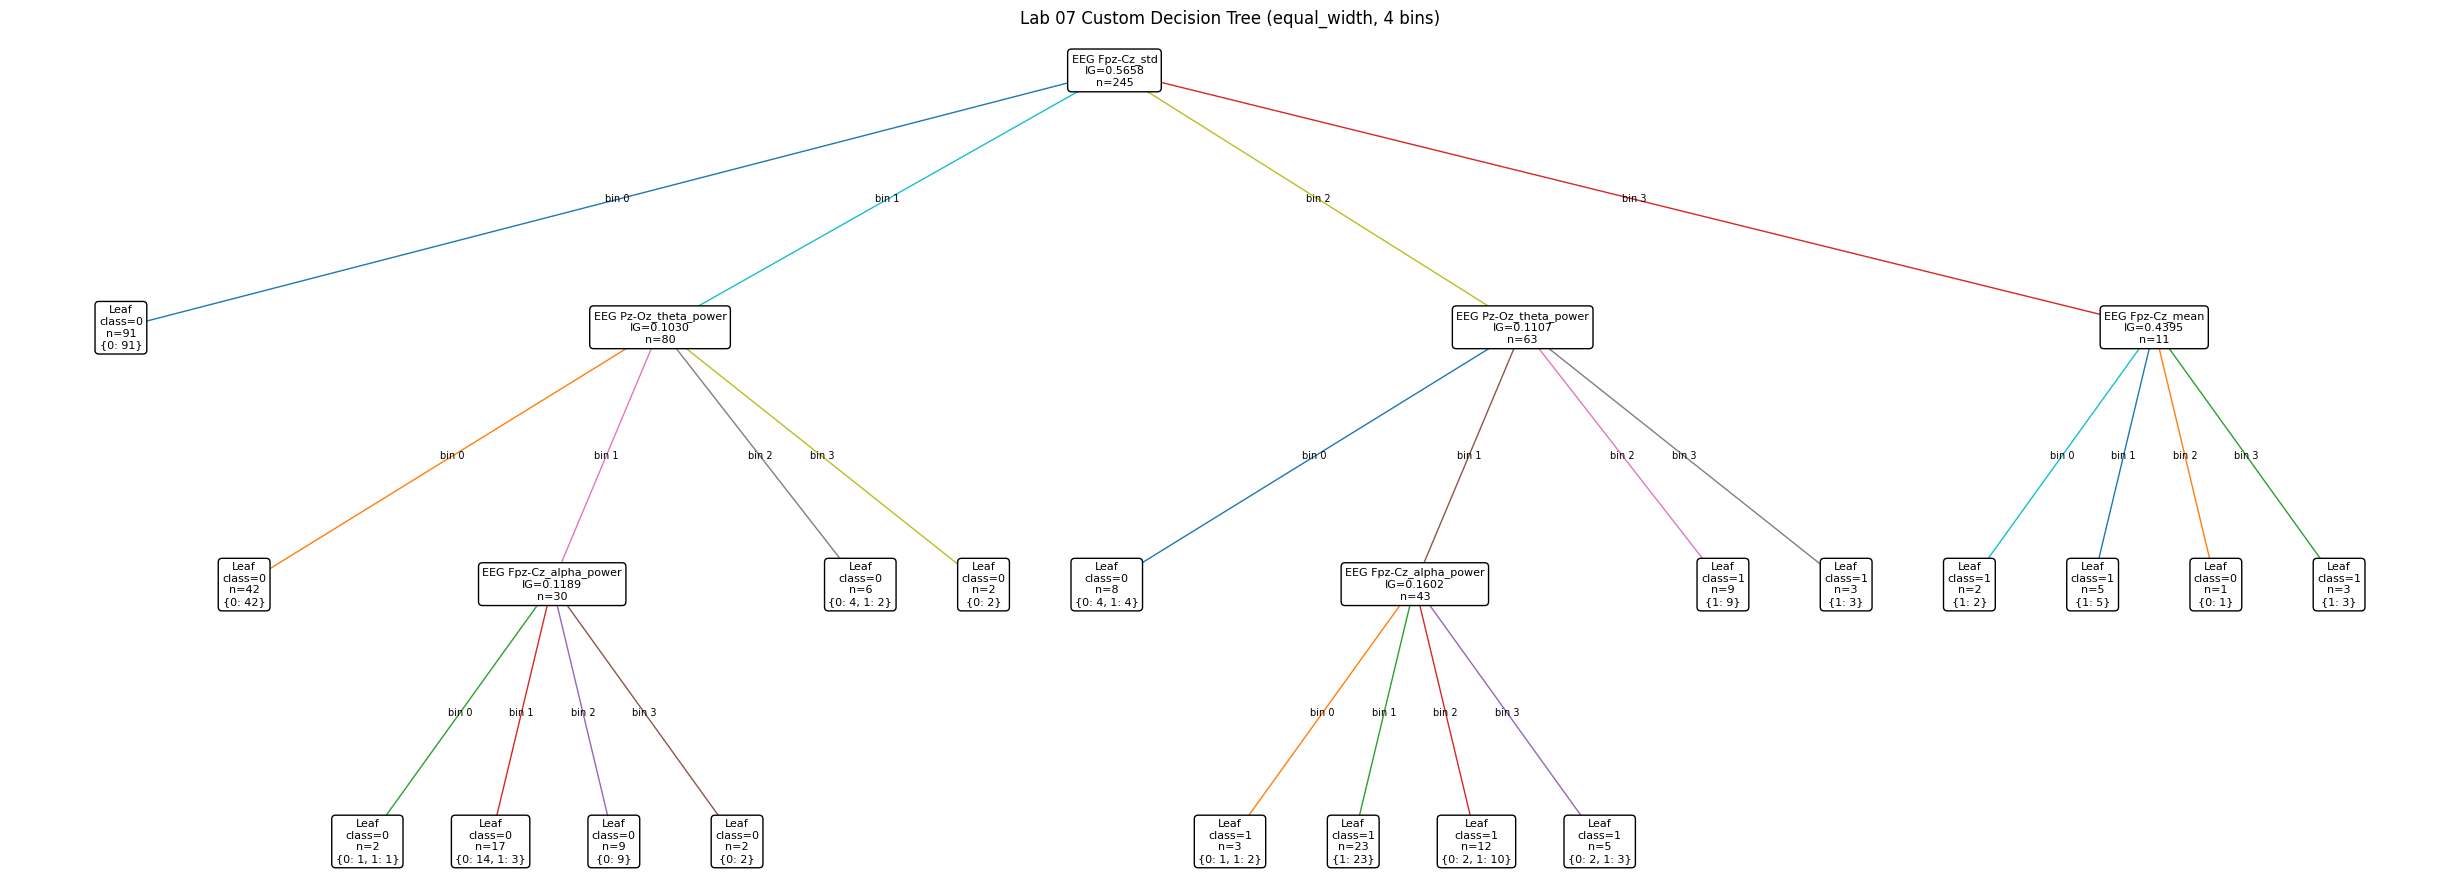

In [12]:

# ============================================================
# A6 — custom tree visualization
# ============================================================

custom_tree_figure, custom_tree_axis = plot_custom_decision_tree(
    custom_tree,
    class_names=[
        "N2",
        "N3"
    ],
    title=(
        "Lab 07 Custom Decision Tree "
        f"({BINNING_TYPE}, {NUMBER_OF_BINS} bins)"
    )
)

custom_tree_figure.savefig(
    "lab07_custom_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# A7 — Two-feature classification and Decision Tree boundary

The two features with the highest Information Gain on the training data are selected automatically.  
A separate custom Decision Tree is trained only on these two features, and its boundary is visualized in the original continuous feature space.


In [13]:

# ============================================================
# A7 — select two strongest features
# ============================================================

top_two_features = (
    information_gain_ranking[
        "feature"
    ]
    .head(2)
    .tolist()
)

top_two_indices = [
    feature_names.index(
        feature_name
    )
    for feature_name
    in top_two_features
]

X_train_two = X_train[
    :,
    top_two_indices
]

X_test_two = X_test[
    :,
    top_two_indices
]

X_all_two = X[
    :,
    top_two_indices
]

X_train_two_binned, two_feature_edges = bin_feature_matrix(
    X_train_two,
    top_two_features,
    binning_type=BINNING_TYPE,
    n_bins=NUMBER_OF_BINS
)

X_test_two_binned, _ = bin_feature_matrix(
    X_test_two,
    top_two_features,
    binning_type=BINNING_TYPE,
    n_bins=NUMBER_OF_BINS,
    fitted_edges=two_feature_edges
)

two_feature_tree = build_custom_decision_tree(
    X_train_two_binned,
    y_train,
    max_depth=3,
    min_samples_split=5
)

two_feature_predictions = predict_custom_tree(
    two_feature_tree,
    X_test_two_binned
)

two_feature_metrics = evaluate_binary_predictions(
    y_test,
    two_feature_predictions
)

print(
    "Selected feature 1:",
    top_two_features[0]
)

print(
    "Selected feature 2:",
    top_two_features[1]
)

print(
    "\nTwo-feature custom-tree test metrics:"
)

display(
    pd.DataFrame([
        two_feature_metrics
    ])
)


Selected feature 1: EEG Fpz-Cz_std
Selected feature 2: EEG Fpz-Cz_rms

Two-feature custom-tree test metrics:


,accuracy,precision,recall,f1_score
0,0.915094,0.892857,0.806452,0.847458


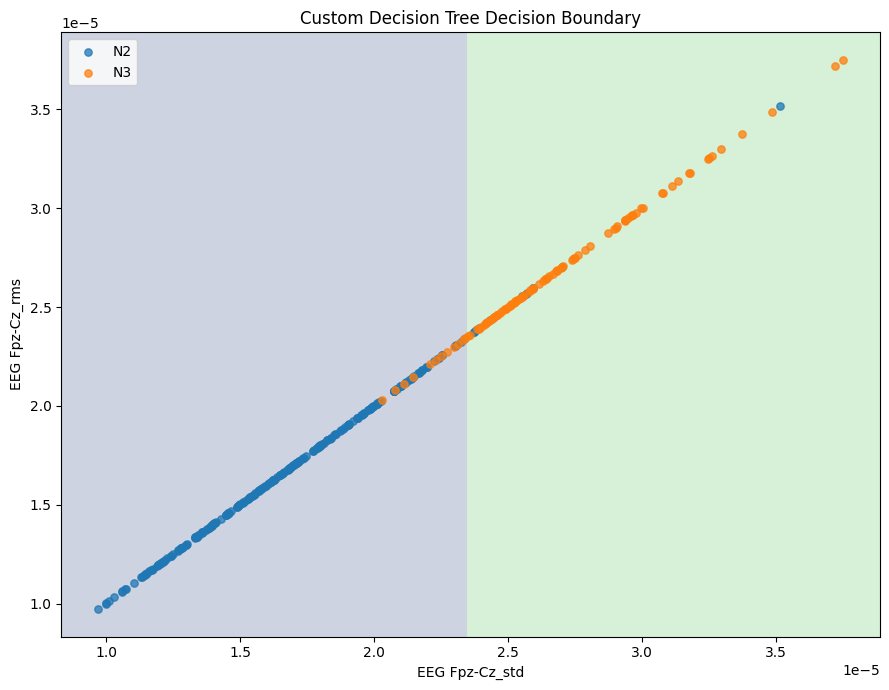

In [14]:

# ============================================================
# A7 — custom Decision Tree decision boundary
# ============================================================

boundary_figure, boundary_axis = plot_custom_tree_decision_boundary(
    two_feature_tree,
    X_all_two,
    y,
    selected_feature_names=top_two_features,
    selected_edges=two_feature_edges,
    class_names=[
        "N2",
        "N3"
    ],
    grid_resolution=250
)

boundary_figure.savefig(
    "lab07_custom_tree_decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# A8 — Hyperparameter tuning with GridSearchCV

For hyperparameter tuning, the inbuilt `DecisionTreeClassifier` is used because `GridSearchCV` expects a scikit-learn-compatible estimator.

The search tests multiple:
- impurity criteria;
- tree depths;
- minimum split sizes;
- minimum leaf sizes;
- feature-selection settings.

`F1` is used as the tuning score because the N2/N3 classes are imbalanced.


In [15]:

# ============================================================
# A8 — GridSearchCV hyperparameter tuning
# ============================================================

base_tree_classifier = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

parameter_grid = {
    "criterion": [
        "entropy",
        "gini"
    ],
    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        None
    ],
    "min_samples_split": [
        2,
        5,
        10
    ],
    "min_samples_leaf": [
        1,
        2,
        4
    ],
    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=base_tree_classifier,
    param_grid=parameter_grid,
    scoring="f1",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

best_tree_classifier = grid_search.best_estimator_

best_test_predictions = best_tree_classifier.predict(
    X_test
)

best_tree_metrics = evaluate_binary_predictions(
    y_test,
    best_test_predictions
)

print(
    "Best hyperparameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest cross-validation F1:",
    f"{grid_search.best_score_:.6f}"
)

print(
    "\nTuned Decision Tree test metrics:"
)

display(
    pd.DataFrame([
        best_tree_metrics
    ])
)

print(
    "\nTuned Decision Tree confusion matrix:"
)

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            best_test_predictions
        ),
        index=[
            "Actual N2",
            "Actual N3"
        ],
        columns=[
            "Predicted N2",
            "Predicted N3"
        ]
    )
)

print(
    "\nTuned Decision Tree classification report:"
)

print(
    classification_report(
        y_test,
        best_test_predictions,
        target_names=[
            "N2",
            "N3"
        ],
        zero_division=0
    )
)


Best hyperparameters:
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation F1: 0.909170

Tuned Decision Tree test metrics:


,accuracy,precision,recall,f1_score
0,0.924528,0.896552,0.83871,0.866667



Tuned Decision Tree confusion matrix:


,Predicted N2,Predicted N3
Actual N2,72,3
Actual N3,5,26



Tuned Decision Tree classification report:
              precision    recall  f1-score   support

          N2       0.94      0.96      0.95        75
          N3       0.90      0.84      0.87        31

    accuracy                           0.92       106
   macro avg       0.92      0.90      0.91       106
weighted avg       0.92      0.92      0.92       106




## A8 — Save the GridSearchCV results and visualize the tuned tree


In [16]:

# ============================================================
# A8 — export tuning results
# ============================================================

grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results = grid_results.sort_values(
    "rank_test_score"
)

selected_grid_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_criterion",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features"
]

top_grid_results = grid_results[
    selected_grid_columns
].head(20)

display(
    top_grid_results
)

top_grid_results.to_csv(
    "lab07_gridsearch_top20.csv",
    index=False
)

tuned_metrics_table = pd.DataFrame([
    {
        "model": "Tuned sklearn Decision Tree",
        **best_tree_metrics
    }
])

tuned_metrics_table.to_csv(
    "lab07_tuned_tree_metrics.csv",
    index=False
)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
209,1,0.909170,0.059403,0.943846,gini,3,10,1,log2
207,1,0.909170,0.059403,0.945679,gini,3,2,1,log2
208,1,0.909170,0.059403,0.945679,gini,3,5,1,log2
180,4,0.895558,0.050577,0.923314,gini,2,2,1,log2
182,4,0.895558,0.050577,0.923314,gini,2,10,1,log2
181,4,0.895558,0.050577,0.923314,gini,2,5,1,log2
173,7,0.891954,0.050092,0.917803,gini,2,10,1,sqrt
172,7,0.891954,0.050092,0.917803,gini,2,5,1,sqrt
171,7,0.891954,0.050092,0.917803,gini,2,2,1,sqrt
10,7,0.891954,0.050092,0.907429,entropy,2,5,1,sqrt


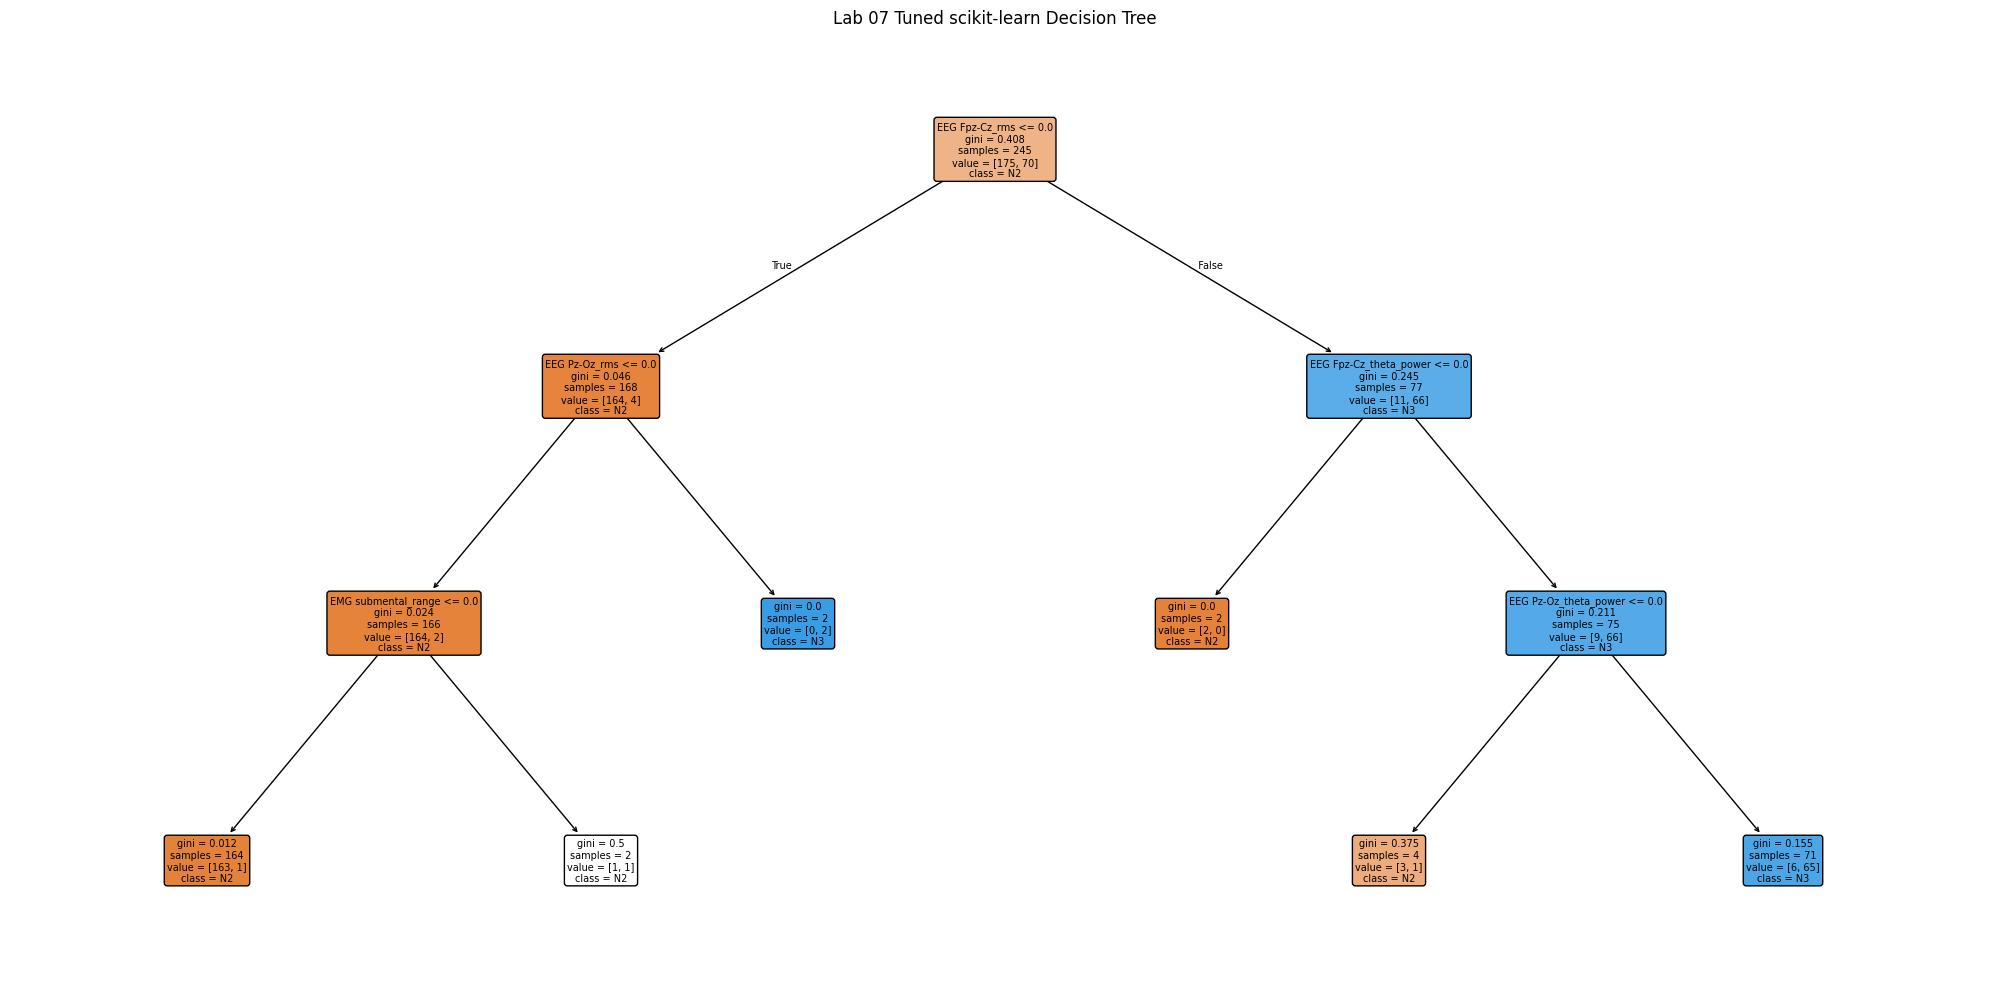

In [17]:

# ============================================================
# A8 — visualize the best sklearn Decision Tree
# ============================================================

plt.figure(
    figsize=(20, 10)
)

plot_tree(
    best_tree_classifier,
    feature_names=feature_names,
    class_names=[
        "N2",
        "N3"
    ],
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=4
)

plt.title(
    "Lab 07 Tuned scikit-learn Decision Tree"
)

plt.tight_layout()

plt.savefig(
    "lab07_tuned_sklearn_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# Lab 07 consolidated results


In [18]:

# ============================================================
# MAIN PROGRAM — consolidated results
# ============================================================

summary_table = pd.DataFrame([
    {
        "item": "Dataset entropy",
        "value": dataset_entropy
    },
    {
        "item": "Dataset Gini index",
        "value": dataset_gini
    },
    {
        "item": "Root Information Gain",
        "value": root_information_gain
    },
    {
        "item": "Custom tree test accuracy",
        "value": custom_test_metrics[
            "accuracy"
        ]
    },
    {
        "item": "Custom tree test F1",
        "value": custom_test_metrics[
            "f1_score"
        ]
    },
    {
        "item": "Tuned sklearn test accuracy",
        "value": best_tree_metrics[
            "accuracy"
        ]
    },
    {
        "item": "Tuned sklearn test F1",
        "value": best_tree_metrics[
            "f1_score"
        ]
    }
])

display(
    summary_table
)

summary_table.to_csv(
    "lab07_summary_results.csv",
    index=False
)

dataset_summary = pd.DataFrame([
    {
        "psg_file": os.path.basename(
            PSG_PATH
        ),
        "hypnogram_file": os.path.basename(
            HYPNOGRAM_PATH
        ),
        "samples": int(
            X.shape[0]
        ),
        "features": int(
            X.shape[1]
        ),
        "N2_count": int(
            np.sum(
                y == 0
            )
        ),
        "N3_count": int(
            np.sum(
                y == 1
            )
        ),
        "train_samples": int(
            X_train.shape[0]
        ),
        "test_samples": int(
            X_test.shape[0]
        ),
        "binning_type": BINNING_TYPE,
        "number_of_bins": NUMBER_OF_BINS,
        "root_feature": root_feature,
        "root_information_gain": root_information_gain,
        "best_grid_parameters": str(
            grid_search.best_params_
        )
    }
])

dataset_summary.to_csv(
    "lab07_dataset_summary.csv",
    index=False
)

print(
    "Lab 07 result CSV files saved."
)


,item,value
0,Dataset entropy,0.865796
1,Dataset Gini index,0.409899
2,Root Information Gain,0.565754
3,Custom tree test accuracy,0.886792
4,Custom tree test F1,0.777778
5,Tuned sklearn test accuracy,0.924528
6,Tuned sklearn test F1,0.866667


Lab 07 result CSV files saved.



# Export all Lab 07 result files

After all cells have executed successfully, this cell creates one ZIP containing the tables and figures needed for the report.


In [19]:

# ============================================================
# MAIN PROGRAM — package report outputs
# ============================================================

result_files = [
    "lab07_information_gain_ranking.csv",
    "lab07_custom_tree_metrics.csv",
    "lab07_gridsearch_top20.csv",
    "lab07_tuned_tree_metrics.csv",
    "lab07_summary_results.csv",
    "lab07_dataset_summary.csv",
    "lab07_custom_decision_tree.png",
    "lab07_custom_tree_decision_boundary.png",
    "lab07_tuned_sklearn_tree.png"
]

existing_files = [
    file_path
    for file_path in result_files
    if os.path.exists(
        file_path
    )
]

output_zip = (
    "Lab07_Sleep_EDF_Decision_Tree_results.zip"
)

with zipfile.ZipFile(
    output_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as archive:
    for file_path in existing_files:
        archive.write(
            file_path,
            arcname=os.path.basename(
                file_path
            )
        )

print(
    f"Created {output_zip}"
)

print(
    f"Files included: {len(existing_files)}"
)

for file_path in existing_files:
    print(
        " -",
        file_path
    )

try:
    from google.colab import files

    files.download(
        output_zip
    )

except ImportError:
    print(
        "Result ZIP saved at:",
        os.path.abspath(
            output_zip
        )
    )


Created Lab07_Sleep_EDF_Decision_Tree_results.zip
Files included: 9
 - lab07_information_gain_ranking.csv
 - lab07_custom_tree_metrics.csv
 - lab07_gridsearch_top20.csv
 - lab07_tuned_tree_metrics.csv
 - lab07_summary_results.csv
 - lab07_dataset_summary.csv
 - lab07_custom_decision_tree.png
 - lab07_custom_tree_decision_boundary.png
 - lab07_tuned_sklearn_tree.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Report observations to record after execution

Use the **actual executed values** from this notebook when updating the Lab 07 report. In particular, discuss:

1. the entropy and Gini impurity of the N2/N3 outcome;
2. the feature selected as the root and its Information Gain;
3. how equal-width and equal-frequency binning distribute the selected continuous feature;
4. training versus test performance of the custom Decision Tree;
5. what the custom tree visualization shows about the first few splits;
6. whether the two strongest features form a clearly separated N2/N3 boundary;
7. the best `GridSearchCV` hyperparameters and cross-validation F1 score;
8. whether the tuned scikit-learn tree improves generalization compared with the manually configured custom tree.

Do not invent values in the report; copy them from the executed notebook/CSV outputs.
